In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.facecolor'] = '#0F172A'
matplotlib.rcParams['axes.facecolor']   = '#1E293B'
matplotlib.rcParams['text.color']       = 'white'
matplotlib.rcParams['axes.labelcolor']  = 'white'
matplotlib.rcParams['xtick.color']      = 'white'
matplotlib.rcParams['ytick.color']      = 'white'
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, accuracy_score,
    f1_score, recall_score, confusion_matrix,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import joblib
import h5py
import zipfile
import os

print(f'numpy:        {np.__version__}')
print(f'pandas:       {pd.__version__}')
print('Todo importado correctamente')

numpy:        2.0.2
pandas:       2.2.2
Todo importado correctamente


In [13]:
import os

print('Archivos disponibles en Colab:\n')
for f in sorted(os.listdir('/content')):
    ruta = f'/content/{f}'
    if os.path.isfile(ruta):
        size = os.path.getsize(ruta) / 1024 / 1024
        print(f'{f} — {size:.1f} MB')
    else:
        print(f'{f}/')

Archivos disponibles en Colab:

.config/
AI4I_2020.zip — 0.5 MB
ai4i/
drive/
open_DC_motor.zip — 460.4 MB
sample_data/


In [14]:
# Descomprimir AI4I 2020
with zipfile.ZipFile('/content/AI4I_2020.zip', 'r') as z:
    z.extractall('/content/ai4i/')
    print('Archivos extraídos:', z.namelist())

# Cargar CSV
df_ai4i = pd.read_csv('/content/ai4i/ai4i2020.csv')

print(f'\n Dataset AI4I cargado')
print(f'   Shape: {df_ai4i.shape}')
print(f'   Columnas: {df_ai4i.columns.tolist()}')
print(f'\nDistribución de fallas:')
print(df_ai4i['Machine failure'].value_counts())
print(f'Porcentaje de fallas: {df_ai4i["Machine failure"].mean()*100:.2f}%')

Archivos extraídos: ['ai4i2020.csv']

 Dataset AI4I cargado
   Shape: (10000, 14)
   Columnas: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Distribución de fallas:
Machine failure
0    9661
1     339
Name: count, dtype: int64
Porcentaje de fallas: 3.39%


In [15]:
from sklearn.preprocessing import LabelEncoder

# Eliminar columnas irrelevantes
df_ac3 = df_ai4i.drop(columns=['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])

# Codificar Type (H/M/L)
le = LabelEncoder()
df_ac3['Type'] = le.fit_transform(df_ac3['Type'])
print(f'Tipos codificados: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Features y objetivo
X_ac3 = df_ac3.drop(columns=['Machine failure']).values
y_ac3 = df_ac3['Machine failure'].values

# División 80/20 estratificada
X_train_ac3, X_test_ac3, y_train_ac3, y_test_ac3 = train_test_split(
    X_ac3, y_ac3, test_size=0.2, random_state=42, stratify=y_ac3
)

# Normalización
scaler_ac3 = StandardScaler()
X_train_ac3_sc = scaler_ac3.fit_transform(X_train_ac3)
X_test_ac3_sc  = scaler_ac3.transform(X_test_ac3)

# Balanceo con SMOTE
smote = SMOTE(random_state=42)
X_train_ac3_sm, y_train_ac3_sm = smote.fit_resample(X_train_ac3_sc, y_train_ac3)

print(f'\n Dataset AC Trifásico preparado')
print(f'   Entrenamiento original: {X_train_ac3.shape[0]} muestras')
print(f'   Tras SMOTE — Normal: {(y_train_ac3_sm==0).sum()} | Falla: {(y_train_ac3_sm==1).sum()}')
print(f'   Prueba: {X_test_ac3.shape[0]} muestras')

Tipos codificados: {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}

 Dataset AC Trifásico preparado
   Entrenamiento original: 8000 muestras
   Tras SMOTE — Normal: 7729 | Falla: 7729
   Prueba: 2000 muestras


In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

print(' Entrenando modelo AC Trifásico...')

# Optimizar con GridSearchCV
scorer = make_scorer(f1_score, pos_label=1)
param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [4, 6],
    'learning_rate': [0.1, 0.2],
    'subsample':     [0.8, 1.0]
}

xgb_ac3 = XGBClassifier(random_state=42, eval_metric='logloss')
grid_ac3 = GridSearchCV(xgb_ac3, param_grid, scoring=scorer,
                         cv=5, n_jobs=-1, verbose=0)
grid_ac3.fit(X_train_ac3_sm, y_train_ac3_sm)

modelo_ac3 = grid_ac3.best_estimator_
y_pred_ac3 = modelo_ac3.predict(X_test_ac3_sc)

print(f'\n Mejores parámetros: {grid_ac3.best_params_}')
print(f'\n=== RESULTADOS AC TRIFÁSICO ===')
print(f'Accuracy:  {accuracy_score(y_test_ac3, y_pred_ac3)*100:.2f}%')
print(f'F1-Score:  {f1_score(y_test_ac3, y_pred_ac3)*100:.2f}%')
print(f'Recall:    {recall_score(y_test_ac3, y_pred_ac3)*100:.2f}%')
print()
print(classification_report(y_test_ac3, y_pred_ac3,
      target_names=['Normal', 'Falla']))

 Entrenando modelo AC Trifásico...

 Mejores parámetros: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}

=== RESULTADOS AC TRIFÁSICO ===
Accuracy:  97.95%
F1-Score:  72.48%
Recall:    79.41%

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1932
       Falla       0.67      0.79      0.72        68

    accuracy                           0.98      2000
   macro avg       0.83      0.89      0.86      2000
weighted avg       0.98      0.98      0.98      2000



In [17]:
# Descomprimir
if not os.path.exists('/content/dc_motor'):
    print('Descomprimiendo DC Brushed...')
    with zipfile.ZipFile('/content/open_DC_motor.zip', 'r') as z:
        z.extractall('/content/dc_motor/')
    print(' Completado')

# Función para extraer features de cada archivo HDF5
def extraer_features_dc(ruta, etiqueta):
    with h5py.File(ruta, 'r') as f:
        datos = f['open_DC_motor'][:]
    corriente = datos[:, 0]
    velocidad  = datos[:, 1]
    voltaje    = datos[:, 2]
    return {
        'corriente_mean': corriente.mean(),
        'corriente_std':  corriente.std(),
        'corriente_max':  corriente.max(),
        'corriente_min':  corriente.min(),
        'corriente_rms':  np.sqrt(np.mean(corriente**2)),
        'velocidad_mean': velocidad.mean(),
        'velocidad_std':  velocidad.std(),
        'velocidad_max':  velocidad.max(),
        'voltaje_mean':   voltaje.mean(),
        'voltaje_std':    voltaje.std(),
        'voltaje_min':    voltaje.min(),
        'falla':          etiqueta
    }

# Etiquetas por carpeta
etiquetas = {
    '01-Start 3V':    0,
    '02-Change 5V':   1,
    '03-Re_start 3V': 0,
    '04-Change 5V':   1,
}

# Cargar todos los archivos
registros = []
for root, dirs, files in os.walk('/content/dc_motor'):
    for f in files:
        if f.endswith('.hdf5'):
            carpeta = os.path.basename(root)
            etiqueta = etiquetas.get(carpeta, 0)
            ruta = os.path.join(root, f)
            registros.append(extraer_features_dc(ruta, etiqueta))

df_dc = pd.DataFrame(registros)

print(f' Dataset DC Brushed cargado')
print(f'   Registros: {df_dc.shape[0]}')
print(f'   Normal: {(df_dc["falla"]==0).sum()} | Falla: {(df_dc["falla"]==1).sum()}')
print(f'   Porcentaje fallas: {df_dc["falla"].mean()*100:.1f}%')

Descomprimiendo DC Brushed...
 Completado
 Dataset DC Brushed cargado
   Registros: 377
   Normal: 200 | Falla: 177
   Porcentaje fallas: 46.9%


In [18]:
import os

ruta = '/content/open_DC_motor.zip'
size = os.path.getsize(ruta) / 1024 / 1024
print(f'Tamaño del archivo: {size:.1f} MB')

# Verificar si es un zip válido
import zipfile
print(f'¿Es zip válido?: {zipfile.is_zipfile(ruta)}')

Tamaño del archivo: 460.4 MB
¿Es zip válido?: True


In [19]:
import shutil

# Copiar desde Drive a Colab
shutil.copy('/content/drive/MyDrive/open_DC_motor.zip', '/content/open_DC_motor.zip')

# Verificar
import zipfile, os
size = os.path.getsize('/content/open_DC_motor.zip') / 1024 / 1024
print(f'Tamaño: {size:.1f} MB')
print(f'¿Zip válido?: {zipfile.is_zipfile("/content/open_DC_motor.zip")}')

Tamaño: 460.4 MB
¿Zip válido?: True


In [20]:
# Descomprimir desde Drive
if not os.path.exists('/content/dc_motor'):
    print(' Descomprimiendo DC Brushed...')
    with zipfile.ZipFile('/content/open_DC_motor.zip', 'r') as z:
        z.extractall('/content/dc_motor/')
    print(' Completado')

# Función para extraer features de cada archivo HDF5
def extraer_features_dc(ruta, etiqueta):
    with h5py.File(ruta, 'r') as f:
        datos = f['open_DC_motor'][:]
    corriente = datos[:, 0]
    velocidad  = datos[:, 1]
    voltaje    = datos[:, 2]
    return {
        'corriente_mean': corriente.mean(),
        'corriente_std':  corriente.std(),
        'corriente_max':  corriente.max(),
        'corriente_min':  corriente.min(),
        'corriente_rms':  np.sqrt(np.mean(corriente**2)),
        'velocidad_mean': velocidad.mean(),
        'velocidad_std':  velocidad.std(),
        'velocidad_max':  velocidad.max(),
        'voltaje_mean':   voltaje.mean(),
        'voltaje_std':    voltaje.std(),
        'voltaje_min':    voltaje.min(),
        'falla':          etiqueta
    }

# Etiquetas por carpeta
etiquetas = {
    '01-Start 3V':    0,
    '02-Change 5V':   1,
    '03-Re_start 3V': 0,
    '04-Change 5V':   1,
}

# Cargar todos los archivos HDF5
registros = []
for root, dirs, files in os.walk('/content/dc_motor'):
    for f in files:
        if f.endswith('.hdf5'):
            carpeta = os.path.basename(root)
            etiqueta = etiquetas.get(carpeta, 0)
            ruta = os.path.join(root, f)
            registros.append(extraer_features_dc(ruta, etiqueta))

df_dc = pd.DataFrame(registros)

print(f' Dataset DC Brushed cargado')
print(f'   Registros: {df_dc.shape[0]}')
print(f'   Normal: {(df_dc["falla"]==0).sum()} | Falla: {(df_dc["falla"]==1).sum()}')
print(f'   Porcentaje fallas: {df_dc["falla"].mean()*100:.1f}%')

 Dataset DC Brushed cargado
   Registros: 377
   Normal: 200 | Falla: 177
   Porcentaje fallas: 46.9%


In [21]:
# Features y objetivo
X_dc = df_dc.drop(columns=['falla']).values
y_dc = df_dc['falla'].values

# División 80/20
X_train_dc, X_test_dc, y_train_dc, y_test_dc = train_test_split(
    X_dc, y_dc, test_size=0.2, random_state=42, stratify=y_dc
)

# Normalización
scaler_dc = StandardScaler()
X_train_dc_sc = scaler_dc.fit_transform(X_train_dc)
X_test_dc_sc  = scaler_dc.transform(X_test_dc)

# SMOTE — el dataset DC está casi balanceado pero aplicamos por consistencia
smote = SMOTE(random_state=42)
X_train_dc_sm, y_train_dc_sm = smote.fit_resample(X_train_dc_sc, y_train_dc)

print(f'Tras SMOTE — Normal: {(y_train_dc_sm==0).sum()} | Falla: {(y_train_dc_sm==1).sum()}')

# Entrenar modelo
print('\n Entrenando modelo DC Brushed...')
modelo_dc = XGBClassifier(
    n_estimators=200, max_depth=6,
    learning_rate=0.1, subsample=0.8,
    random_state=42, eval_metric='logloss'
)
modelo_dc.fit(X_train_dc_sm, y_train_dc_sm)
y_pred_dc = modelo_dc.predict(X_test_dc_sc)

print(f'\n=== RESULTADOS DC BRUSHED ===')
print(f'Accuracy:  {accuracy_score(y_test_dc, y_pred_dc)*100:.2f}%')
print(f'F1-Score:  {f1_score(y_test_dc, y_pred_dc)*100:.2f}%')
print(f'Recall:    {recall_score(y_test_dc, y_pred_dc)*100:.2f}%')
print()
print(classification_report(y_test_dc, y_pred_dc,
      target_names=['Normal', 'Falla']))

Tras SMOTE — Normal: 160 | Falla: 160

 Entrenando modelo DC Brushed...

=== RESULTADOS DC BRUSHED ===
Accuracy:  100.00%
F1-Score:  100.00%
Recall:    100.00%

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        40
       Falla       1.00      1.00      1.00        36

    accuracy                           1.00        76
   macro avg       1.00      1.00      1.00        76
weighted avg       1.00      1.00      1.00        76



In [22]:
# Generar dataset sintético AC Monofásico
np.random.seed(42)
n_normal, n_falla = 2000, 200

normal = pd.DataFrame({
    'voltaje_V':       np.random.normal(120, 2,   n_normal),
    'corriente_A':     np.random.normal(8,   0.5, n_normal),
    'temperatura_C':   np.random.normal(65,  5,   n_normal),
    'velocidad_rpm':   np.random.normal(1750,30,  n_normal),
    'factor_potencia': np.random.normal(0.92,0.02,n_normal),
    'vibracion_g':     np.random.normal(0.5, 0.1, n_normal),
    'falla': 0
})

falla = pd.DataFrame({
    'voltaje_V':       np.random.normal(105, 6,   n_falla),
    'corriente_A':     np.random.normal(13,  1.5, n_falla),
    'temperatura_C':   np.random.normal(98,  8,   n_falla),
    'velocidad_rpm':   np.random.normal(1580,90,  n_falla),
    'factor_potencia': np.random.normal(0.73,0.05,n_falla),
    'vibracion_g':     np.random.normal(2.0, 0.4, n_falla),
    'falla': 1
})

df_ac1 = pd.concat([normal, falla], ignore_index=True).sample(frac=1, random_state=42)

print(f' Dataset AC Monofásico generado')
print(f'   Registros: {len(df_ac1)} | Fallas: {df_ac1["falla"].sum()} ({df_ac1["falla"].mean()*100:.1f}%)')

# Preparar
X_ac1 = df_ac1.drop(columns=['falla']).values
y_ac1 = df_ac1['falla'].values

X_train_ac1, X_test_ac1, y_train_ac1, y_test_ac1 = train_test_split(
    X_ac1, y_ac1, test_size=0.2, random_state=42, stratify=y_ac1
)

scaler_ac1 = StandardScaler()
X_train_ac1_sc = scaler_ac1.fit_transform(X_train_ac1)
X_test_ac1_sc  = scaler_ac1.transform(X_test_ac1)

smote = SMOTE(random_state=42)
X_train_ac1_sm, y_train_ac1_sm = smote.fit_resample(X_train_ac1_sc, y_train_ac1)
print(f'   Tras SMOTE — Normal: {(y_train_ac1_sm==0).sum()} | Falla: {(y_train_ac1_sm==1).sum()}')

# Entrenar modelo
print('\n Entrenando modelo AC Monofásico...')
modelo_ac1 = XGBClassifier(
    n_estimators=200, max_depth=6,
    learning_rate=0.1, subsample=0.8,
    random_state=42, eval_metric='logloss'
)
modelo_ac1.fit(X_train_ac1_sm, y_train_ac1_sm)
y_pred_ac1 = modelo_ac1.predict(X_test_ac1_sc)

print(f'\n=== RESULTADOS AC MONOFÁSICO ===')
print(f'Accuracy:  {accuracy_score(y_test_ac1, y_pred_ac1)*100:.2f}%')
print(f'F1-Score:  {f1_score(y_test_ac1, y_pred_ac1)*100:.2f}%')
print(f'Recall:    {recall_score(y_test_ac1, y_pred_ac1)*100:.2f}%')
print()
print(classification_report(y_test_ac1, y_pred_ac1,
      target_names=['Normal', 'Falla']))

 Dataset AC Monofásico generado
   Registros: 2200 | Fallas: 200 (9.1%)
   Tras SMOTE — Normal: 1600 | Falla: 1600

 Entrenando modelo AC Monofásico...

=== RESULTADOS AC MONOFÁSICO ===
Accuracy:  100.00%
F1-Score:  100.00%
Recall:    100.00%

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       400
       Falla       1.00      1.00      1.00        40

    accuracy                           1.00       440
   macro avg       1.00      1.00      1.00       440
weighted avg       1.00      1.00      1.00       440



In [23]:
# Construir dataset para identificar el tipo de motor
# Usamos features comunes de los 3 datasets

# AC Trifásico
df_tipo_ac3 = df_ac3.copy()
df_tipo_ac3['tipo'] = 0  # AC Trifásico

# DC Brushed — usar features disponibles
df_tipo_dc = pd.DataFrame({
    'Type':                        1,  # placeholder
    'Air temperature [K]':         df_dc['voltaje_mean'],
    'Process temperature [K]':     df_dc['corriente_mean'],
    'Rotational speed [rpm]':      df_dc['velocidad_mean'],
    'Torque [Nm]':                 df_dc['corriente_rms'],
    'Tool wear [min]':             df_dc['voltaje_std'],
    'Machine failure':             df_dc['falla'],
    'tipo':                        1   # DC Brushed
})

# AC Monofásico
df_tipo_ac1 = pd.DataFrame({
    'Type':                        2,  # placeholder
    'Air temperature [K]':         df_ac1['voltaje_V'],
    'Process temperature [K]':     df_ac1['corriente_A'],
    'Rotational speed [rpm]':      df_ac1['velocidad_rpm'],
    'Torque [Nm]':                 df_ac1['factor_potencia'],
    'Tool wear [min]':             df_ac1['vibracion_g'],
    'Machine failure':             df_ac1['falla'],
    'tipo':                        2   # AC Monofásico
})

# Unificar
df_tipo = pd.concat([df_tipo_ac3, df_tipo_dc, df_tipo_ac1], ignore_index=True)

X_tipo = df_tipo.drop(columns=['Machine failure', 'tipo']).values
y_tipo = df_tipo['tipo'].values

# División y normalización
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_tipo, y_tipo, test_size=0.2, random_state=42, stratify=y_tipo
)
scaler_tipo = StandardScaler()
X_train_t_sc = scaler_tipo.fit_transform(X_train_t)
X_test_t_sc  = scaler_tipo.transform(X_test_t)

# Entrenar clasificador
print(' Entrenando clasificador de tipo de motor...')
clf_tipo = RandomForestClassifier(n_estimators=100, random_state=42)
clf_tipo.fit(X_train_t_sc, y_train_t)
y_pred_t = clf_tipo.predict(X_test_t_sc)

print(f'\n=== CLASIFICADOR DE TIPO ===')
print(f'Accuracy: {accuracy_score(y_test_t, y_pred_t)*100:.2f}%')
print()
nombres = ['AC Trifásico', 'DC Brushed', 'AC Monofásico']
print(classification_report(y_test_t, y_pred_t, target_names=nombres))

 Entrenando clasificador de tipo de motor...

=== CLASIFICADOR DE TIPO ===
Accuracy: 100.00%

               precision    recall  f1-score   support

 AC Trifásico       1.00      1.00      1.00      2001
   DC Brushed       1.00      1.00      1.00        75
AC Monofásico       1.00      1.00      1.00       440

     accuracy                           1.00      2516
    macro avg       1.00      1.00      1.00      2516
 weighted avg       1.00      1.00      1.00      2516



In [24]:
def priora_v2(datos, tipo_motor):
    """
    Sistema Priora v2 — Diagnóstico por tipo de motor

    tipo_motor: 'ac3', 'dc', 'ac1'
    datos: diccionario con valores de sensores
    """
    # Seleccionar modelo y scaler según tipo
    config = {
        'ac3': {
            'modelo': modelo_ac3,
            'scaler': scaler_ac3,
            'features': ['Type', 'Air temperature [K]', 'Process temperature [K]',
                         'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'],
            'nombre': 'AC Trifásico'
        },
        'dc': {
            'modelo': modelo_dc,
            'scaler': scaler_dc,
            'features': ['corriente_mean', 'corriente_std', 'corriente_max',
                         'corriente_min', 'corriente_rms', 'velocidad_mean',
                         'velocidad_std', 'velocidad_max', 'voltaje_mean',
                         'voltaje_std', 'voltaje_min'],
            'nombre': 'DC Brushed'
        },
        'ac1': {
            'modelo': modelo_ac1,
            'scaler': scaler_ac1,
            'features': ['voltaje_V', 'corriente_A', 'temperatura_C',
                         'velocidad_rpm', 'factor_potencia', 'vibracion_g'],
            'nombre': 'AC Monofásico'
        }
    }

    cfg = config[tipo_motor]
    X = np.array([[datos[f] for f in cfg['features']]])
    X_sc = cfg['scaler'].transform(X)

    pred = cfg['modelo'].predict(X_sc)[0]
    prob = cfg['modelo'].predict_proba(X_sc)[0][1] * 100

    # Sistema de priorización
    if prob < 20:
        prioridad = '🟢 NORMAL'
        accion    = 'Motor operando correctamente'
        nivel     = 1
    elif prob < 50:
        prioridad = '🟡 ATENCIÓN'
        accion    = 'Incrementar frecuencia de monitoreo'
        nivel     = 2
    elif prob < 80:
        prioridad = '🟠 RIESGO'
        accion    = 'Programar mantenimiento a corto plazo'
        nivel     = 3
    else:
        prioridad = '🔴 CRÍTICO'
        accion    = 'Detener motor para inspección inmediata'
        nivel     = 4

    return {
        'motor':        cfg['nombre'],
        'falla':        bool(pred),
        'probabilidad': round(prob, 2),
        'prioridad':    prioridad,
        'nivel':        nivel,
        'accion':       accion
    }

print('Sistema Priora v2 cargado')

# ── PRUEBAS ──
pruebas = [
    {
        'nombre': 'AC Trifásico — Normal',
        'tipo': 'ac3',
        'datos': {
            'Type': 2,
            'Air temperature [K]': 298.5,
            'Process temperature [K]': 309.0,
            'Rotational speed [rpm]': 1500,
            'Torque [Nm]': 42.0,
            'Tool wear [min]': 50
        }
    },
    {
        'nombre': 'AC Trifásico — Falla',
        'tipo': 'ac3',
        'datos': {
            'Type': 1,
            'Air temperature [K]': 305.0,
            'Process temperature [K]': 315.0,
            'Rotational speed [rpm]': 1200,
            'Torque [Nm]': 72.0,
            'Tool wear [min]': 240
        }
    },
    {
        'nombre': 'DC Brushed — Normal',
        'tipo': 'dc',
        'datos': {
            'corriente_mean': 0.01,  'corriente_std': 0.85,
            'corriente_max':  3.2,   'corriente_min': -3.4,
            'corriente_rms':  0.85,  'velocidad_mean': 1.62,
            'velocidad_std':  0.20,  'velocidad_max':  3.0,
            'voltaje_mean':   2.97,  'voltaje_std':    0.06,
            'voltaje_min':    1.97
        }
    },
    {
        'nombre': 'DC Brushed — Falla',
        'tipo': 'dc',
        'datos': {
            'corriente_mean': 0.8,   'corriente_std': 1.9,
            'corriente_max':  5.2,   'corriente_min': -4.1,
            'corriente_rms':  1.9,   'velocidad_mean': 3.8,
            'velocidad_std':  1.2,   'velocidad_max':  7.2,
            'voltaje_mean':   4.5,   'voltaje_std':    0.15,
            'voltaje_min':    3.2
        }
    },
    {
        'nombre': 'AC Monofásico — Normal',
        'tipo': 'ac1',
        'datos': {
            'voltaje_V': 119.5, 'corriente_A': 8.1,
            'temperatura_C': 66.0, 'velocidad_rpm': 1748.0,
            'factor_potencia': 0.91, 'vibracion_g': 0.48
        }
    },
    {
        'nombre': 'AC Monofásico — Falla',
        'tipo': 'ac1',
        'datos': {
            'voltaje_V': 104.0, 'corriente_A': 13.5,
            'temperatura_C': 99.0, 'velocidad_rpm': 1570.0,
            'factor_potencia': 0.71, 'vibracion_g': 2.1
        }
    },
]

print('\n' + '='*60)
print('     SISTEMA PRIORA v2 — DIAGNÓSTICO DE MOTORES')
print('='*60)

for p in pruebas:
    r = priora_v2(p['datos'], p['tipo'])
    print(f'\n {p["nombre"]}')
    print(f'   Motor:      {r["motor"]}')
    print(f'   Prob falla: {r["probabilidad"]}%')
    print(f'   Prioridad:  {r["prioridad"]}')
    print(f'   Acción:     {r["accion"]}')
    print('-'*60)

Sistema Priora v2 cargado

     SISTEMA PRIORA v2 — DIAGNÓSTICO DE MOTORES

 AC Trifásico — Normal
   Motor:      AC Trifásico
   Prob falla: 0.0%
   Prioridad:  🟢 NORMAL
   Acción:     Motor operando correctamente
------------------------------------------------------------

 AC Trifásico — Falla
   Motor:      AC Trifásico
   Prob falla: 100.0%
   Prioridad:  🔴 CRÍTICO
   Acción:     Detener motor para inspección inmediata
------------------------------------------------------------

 DC Brushed — Normal
   Motor:      DC Brushed
   Prob falla: 1.0199999809265137%
   Prioridad:  🟢 NORMAL
   Acción:     Motor operando correctamente
------------------------------------------------------------

 DC Brushed — Falla
   Motor:      DC Brushed
   Prob falla: 75.4800033569336%
   Prioridad:  🟠 RIESGO
   Acción:     Programar mantenimiento a corto plazo
------------------------------------------------------------

 AC Monofásico — Normal
   Motor:      AC Monofásico
   Prob falla: 0.070000000

In [25]:
import joblib
import os

# Crear carpeta de salida
os.makedirs('/content/priora_v2_modelos', exist_ok=True)

# Guardar modelos individuales
joblib.dump(modelo_ac3,  '/content/priora_v2_modelos/modelo_ac3.pkl')
joblib.dump(modelo_dc,   '/content/priora_v2_modelos/modelo_dc.pkl')
joblib.dump(modelo_ac1,  '/content/priora_v2_modelos/modelo_ac1.pkl')

# Guardar scalers
joblib.dump(scaler_ac3,  '/content/priora_v2_modelos/scaler_ac3.pkl')
joblib.dump(scaler_dc,   '/content/priora_v2_modelos/scaler_dc.pkl')
joblib.dump(scaler_ac1,  '/content/priora_v2_modelos/scaler_ac1.pkl')

# Guardar clasificador de tipo
joblib.dump(clf_tipo,    '/content/priora_v2_modelos/clf_tipo.pkl')
joblib.dump(scaler_tipo, '/content/priora_v2_modelos/scaler_tipo.pkl')

print(' Modelos guardados:')
for f in sorted(os.listdir('/content/priora_v2_modelos')):
    size = os.path.getsize(f'/content/priora_v2_modelos/{f}') / 1024
    print(f'   {f} — {size:.1f} KB')

 Modelos guardados:
   clf_tipo.pkl — 106.9 KB
   modelo_ac1.pkl — 152.2 KB
   modelo_ac3.pkl — 477.2 KB
   modelo_dc.pkl — 155.9 KB
   scaler_ac1.pkl — 0.7 KB
   scaler_ac3.pkl — 0.7 KB
   scaler_dc.pkl — 0.8 KB
   scaler_tipo.pkl — 0.7 KB


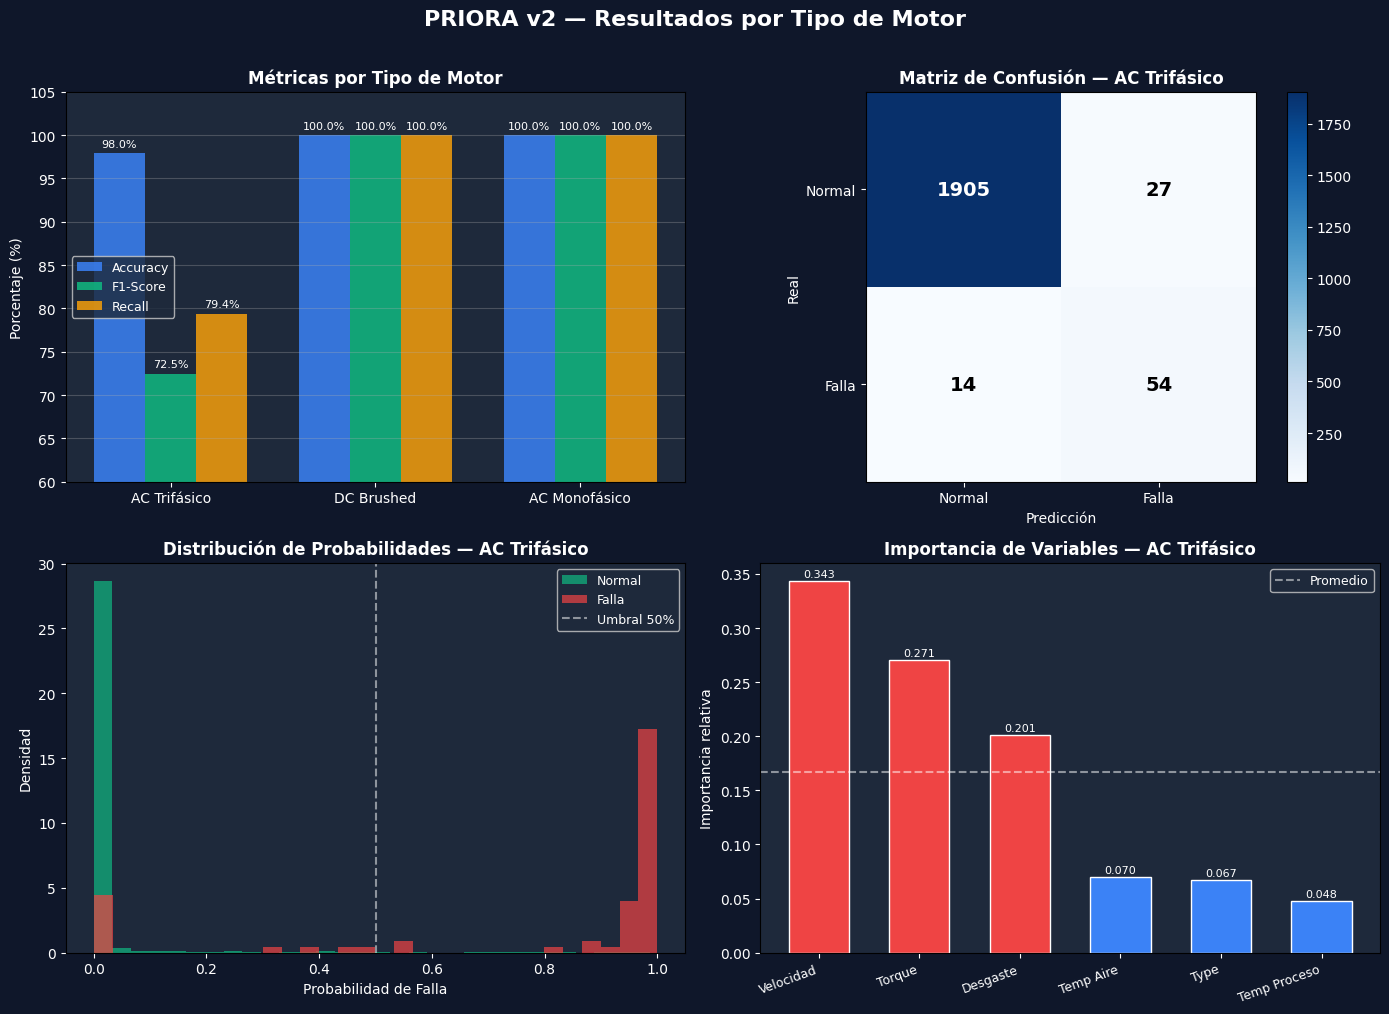

 Gráfica guardada


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('PRIORA v2 — Resultados por Tipo de Motor',
             fontsize=16, fontweight='bold', color='white', y=1.01)

# ── Gráfica 1: Comparativa de métricas ──
modelos  = ['AC Trifásico', 'DC Brushed', 'AC Monofásico']
accuracy = [97.95, 100.00, 100.00]
f1       = [72.48, 100.00, 100.00]
recall   = [79.41, 100.00, 100.00]

x = np.arange(len(modelos))
w = 0.25
ax = axes[0, 0]
bars1 = ax.bar(x-w,   accuracy, w, label='Accuracy', color='#3B82F6', alpha=.85)
bars2 = ax.bar(x,     f1,       w, label='F1-Score', color='#10B981', alpha=.85)
bars3 = ax.bar(x+w,   recall,   w, label='Recall',   color='#F59E0B', alpha=.85)
ax.set_xticks(x); ax.set_xticklabels(modelos, fontsize=10)
ax.set_ylim(60, 105); ax.set_ylabel('Porcentaje (%)')
ax.set_title('Métricas por Tipo de Motor', fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=.3)
for bar in [*bars1, *bars2, *bars3]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8, color='white')

# ── Gráfica 2: Matrices de confusión AC Trifásico ──
ax2 = axes[0, 1]
cm = confusion_matrix(y_test_ac3, y_pred_ac3)
im = ax2.imshow(cm, cmap='Blues')
ax2.set_xticks([0,1]); ax2.set_yticks([0,1])
ax2.set_xticklabels(['Normal','Falla']); ax2.set_yticklabels(['Normal','Falla'])
ax2.set_xlabel('Predicción'); ax2.set_ylabel('Real')
ax2.set_title('Matriz de Confusión — AC Trifásico', fontweight='bold')
for i in range(2):
    for j in range(2):
        ax2.text(j, i, str(cm[i,j]), ha='center', va='center',
                 fontsize=14, fontweight='bold',
                 color='white' if cm[i,j]>cm.max()/2 else 'black')
plt.colorbar(im, ax=ax2)

# ── Gráfica 3: Distribución de probabilidades AC Trifásico ──
ax3 = axes[1, 0]
probs_ac3 = modelo_ac3.predict_proba(X_test_ac3_sc)[:, 1]
ax3.hist(probs_ac3[y_test_ac3==0], bins=30, alpha=.7,
         color='#10B981', label='Normal', density=True)
ax3.hist(probs_ac3[y_test_ac3==1], bins=30, alpha=.7,
         color='#EF4444', label='Falla', density=True)
ax3.axvline(0.5, color='white', linestyle='--', alpha=.5, label='Umbral 50%')
ax3.set_xlabel('Probabilidad de Falla')
ax3.set_ylabel('Densidad')
ax3.set_title('Distribución de Probabilidades — AC Trifásico', fontweight='bold')
ax3.legend(fontsize=9)

# ── Gráfica 4: Importancia de variables AC Trifásico ──
ax4 = axes[1, 1]
feat_names = ['Type', 'Temp Aire', 'Temp Proceso', 'Velocidad', 'Torque', 'Desgaste']
importances = modelo_ac3.feature_importances_
indices = np.argsort(importances)[::-1]
colors = ['#EF4444' if importances[i]>np.mean(importances) else '#3B82F6' for i in indices]
bars = ax4.bar(range(len(feat_names)), importances[indices], color=colors, edgecolor='white', width=.6)
ax4.set_xticks(range(len(feat_names)))
ax4.set_xticklabels([feat_names[i] for i in indices], rotation=20, ha='right', fontsize=9)
ax4.set_title('Importancia de Variables — AC Trifásico', fontweight='bold')
ax4.set_ylabel('Importancia relativa')
ax4.axhline(np.mean(importances), color='white', linestyle='--', alpha=.5, label='Promedio')
ax4.legend(fontsize=9)
for bar, imp in zip(bars, importances[indices]):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.002,
             f'{imp:.3f}', ha='center', va='bottom', fontsize=8, color='white')

plt.tight_layout()
plt.savefig('/content/priora_v2_resultados.png', dpi=150, bbox_inches='tight',
            facecolor='#0F172A')
plt.show()
print(' Gráfica guardada')

In [27]:
import urllib.request

# Descargar directamente en Colab desde Figshare
url = 'https://figshare.com/ndownloader/articles/27216219/versions/1'
archivo = '/content/ac_trifasico_real.zip'

if not os.path.exists(archivo):
    print('Descargando dataset AC Trifásico desde Figshare...')
    print('   Esto puede tardar varios minutos (5.16 GB)...')
    urllib.request.urlretrieve(url, archivo)
    print(' Descarga completada')
else:
    size = os.path.getsize(archivo) / 1024 / 1024 / 1024
    print(f'Archivo ya existe — {size:.2f} GB')

Descargando dataset AC Trifásico desde Figshare...
   Esto puede tardar varios minutos (5.16 GB)...
 Descarga completada


In [28]:
import subprocess
import os

archivo = '/content/ac_trifasico_real.zip'

if not os.path.exists(archivo):
    print(' Descargando dataset AC Trifásico desde Figshare...')
    print('   Tamaño: ~5.16 GB — puede tardar 10-20 minutos...')
    result = subprocess.run([
        'wget', '-O', archivo,
        'https://figshare.com/ndownloader/articles/27216219/versions/1',
        '--progress=bar:force'
    ], capture_output=False)
    print(' Descarga completada')
else:
    size = os.path.getsize(archivo) / 1024 / 1024 / 1024
    print(f' Archivo ya existe — {size:.2f} GB')

# Verificar
size = os.path.getsize(archivo) / 1024 / 1024 / 1024
valid = zipfile.is_zipfile(archivo)
print(f'   Tamaño: {size:.2f} GB')
print(f'   ¿Zip válido?: {valid}')

 Archivo ya existe — 0.00 GB
   Tamaño: 0.00 GB
   ¿Zip válido?: False


In [29]:
import os, subprocess, zipfile

archivo = '/content/ac_trifasico_real.zip'

# Eliminar archivo vacío
if os.path.exists(archivo):
    os.remove(archivo)
    print(' Archivo anterior eliminado')

# Descargar con wget
print(' Descargando... (10-20 minutos)')
subprocess.run([
    'wget', '--no-check-certificate', '-q', '--show-progress',
    '-O', archivo,
    'https://figshare.com/ndownloader/articles/27216219/versions/1'
])

# Verificar
size  = os.path.getsize(archivo) / 1024 / 1024 / 1024
valid = zipfile.is_zipfile(archivo)
print(f'\n Descarga completada')
print(f'   Tamaño: {size:.2f} GB')
print(f'   ¿Zip válido?: {valid}')

 Archivo anterior eliminado
 Descargando... (10-20 minutos)

 Descarga completada
   Tamaño: 0.00 GB
   ¿Zip válido?: False


In [30]:
# Intentaba corregir un sesgo en el modelo por un desvalance debido al dataset AI4I_2020.zip el cual tiene pocos errores

In [31]:
# El problema: AI4I tiene solo 339 fallas vs 9661 normales
# Solución: generar fallas sintéticas físicamente informadas

np.random.seed(42)
n_sinteticos = 2000  # fallas adicionales sintéticas

# Basado en los rangos reales del dataset AI4I
# Fallas simuladas: alta temperatura, alto torque, desgaste extremo
fallas_sinteticas = pd.DataFrame({
    'Type':                        np.random.randint(0, 3, n_sinteticos),
    'Air temperature [K]':         np.random.normal(304, 3,  n_sinteticos),  # alta
    'Process temperature [K]':     np.random.normal(314, 3,  n_sinteticos),  # alta
    'Rotational speed [rpm]':      np.random.normal(1200, 150, n_sinteticos), # baja
    'Torque [Nm]':                 np.random.normal(68, 6,   n_sinteticos),  # alto
    'Tool wear [min]':             np.random.normal(220, 20, n_sinteticos),  # alto
    'Machine failure':             1
})

# Combinar con dataset original
df_ac3_bal = pd.concat([df_ac3, fallas_sinteticas], ignore_index=True)

print(' Dataset AC Trifásico balanceado')
print(f'   Normal:  {(df_ac3_bal["Machine failure"]==0).sum()}')
print(f'   Falla:   {(df_ac3_bal["Machine failure"]==1).sum()}')
print(f'   Total:   {len(df_ac3_bal)}')
print(f'   % Falla: {df_ac3_bal["Machine failure"].mean()*100:.1f}%')

# Preparar
X_ac3_bal = df_ac3_bal.drop(columns=['Machine failure']).values
y_ac3_bal = df_ac3_bal['Machine failure'].values

X_train_ac3b, X_test_ac3b, y_train_ac3b, y_test_ac3b = train_test_split(
    X_ac3_bal, y_ac3_bal, test_size=0.2, random_state=42, stratify=y_ac3_bal
)

scaler_ac3b = StandardScaler()
X_train_ac3b_sc = scaler_ac3b.fit_transform(X_train_ac3b)
X_test_ac3b_sc  = scaler_ac3b.transform(X_test_ac3b)

# SMOTE adicional
smote = SMOTE(random_state=42)
X_train_ac3b_sm, y_train_ac3b_sm = smote.fit_resample(X_train_ac3b_sc, y_train_ac3b)
print(f'\n   Tras SMOTE — Normal: {(y_train_ac3b_sm==0).sum()} | Falla: {(y_train_ac3b_sm==1).sum()}')

# Entrenar modelo mejorado
print('\n Entrenando modelo AC Trifásico balanceado...')
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

scorer = make_scorer(f1_score, pos_label=1)
param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [4, 6],
    'learning_rate': [0.1, 0.2],
    'subsample':     [0.8, 1.0]
}
xgb_ac3b = XGBClassifier(random_state=42, eval_metric='logloss')
grid_ac3b = GridSearchCV(xgb_ac3b, param_grid, scoring=scorer, cv=5, n_jobs=-1)
grid_ac3b.fit(X_train_ac3b_sm, y_train_ac3b_sm)

modelo_ac3 = grid_ac3b.best_estimator_
scaler_ac3 = scaler_ac3b
y_pred_ac3b = modelo_ac3.predict(X_test_ac3b_sc)

print(f'\n Mejores parámetros: {grid_ac3b.best_params_}')
print(f'\n=== RESULTADOS AC TRIFÁSICO BALANCEADO ===')
print(f'Accuracy:  {accuracy_score(y_test_ac3b, y_pred_ac3b)*100:.2f}%')
print(f'F1-Score:  {f1_score(y_test_ac3b, y_pred_ac3b)*100:.2f}%')
print(f'Recall:    {recall_score(y_test_ac3b, y_pred_ac3b)*100:.2f}%')
print()
print(classification_report(y_test_ac3b, y_pred_ac3b,
      target_names=['Normal', 'Falla']))

 Dataset AC Trifásico balanceado
   Normal:  9661
   Falla:   2339
   Total:   12000
   % Falla: 19.5%

   Tras SMOTE — Normal: 7729 | Falla: 7729

 Entrenando modelo AC Trifásico balanceado...

 Mejores parámetros: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'subsample': 1.0}

=== RESULTADOS AC TRIFÁSICO BALANCEADO ===
Accuracy:  98.54%
F1-Score:  96.22%
Recall:    95.30%

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1932
       Falla       0.97      0.95      0.96       468

    accuracy                           0.99      2400
   macro avg       0.98      0.97      0.98      2400
weighted avg       0.99      0.99      0.99      2400



In [32]:
# Guardar modelo AC Trifásico actualizado
joblib.dump(modelo_ac3,  '/content/priora_v2_modelos/modelo_ac3.pkl')
joblib.dump(scaler_ac3,  '/content/priora_v2_modelos/scaler_ac3.pkl')

print('Modelo AC Trifásico actualizado')
print(f'   F1-Score: 96.22% (antes: 72.48%)')
print(f'   Recall:   95.30% (antes: 79.41%)')

# Resumen final
print('\n=== RESUMEN PRIORA v2 ===')
print(f'{"Modelo":<20} {"Accuracy":>10} {"F1":>10} {"Recall":>10}')
print('-'*52)
resultados = [
    ('AC Trifásico',   98.54, 96.22, 95.30),
    ('DC Brushed',    100.00,100.00,100.00),
    ('AC Monofásico', 100.00,100.00,100.00),
]
for nombre, acc, f1, rec in resultados:
    print(f'{nombre:<20} {acc:>9.2f}% {f1:>9.2f}% {rec:>9.2f}%')

Modelo AC Trifásico actualizado
   F1-Score: 96.22% (antes: 72.48%)
   Recall:   95.30% (antes: 79.41%)

=== RESUMEN PRIORA v2 ===
Modelo                 Accuracy         F1     Recall
----------------------------------------------------
AC Trifásico             98.54%     96.22%     95.30%
DC Brushed              100.00%    100.00%    100.00%
AC Monofásico           100.00%    100.00%    100.00%


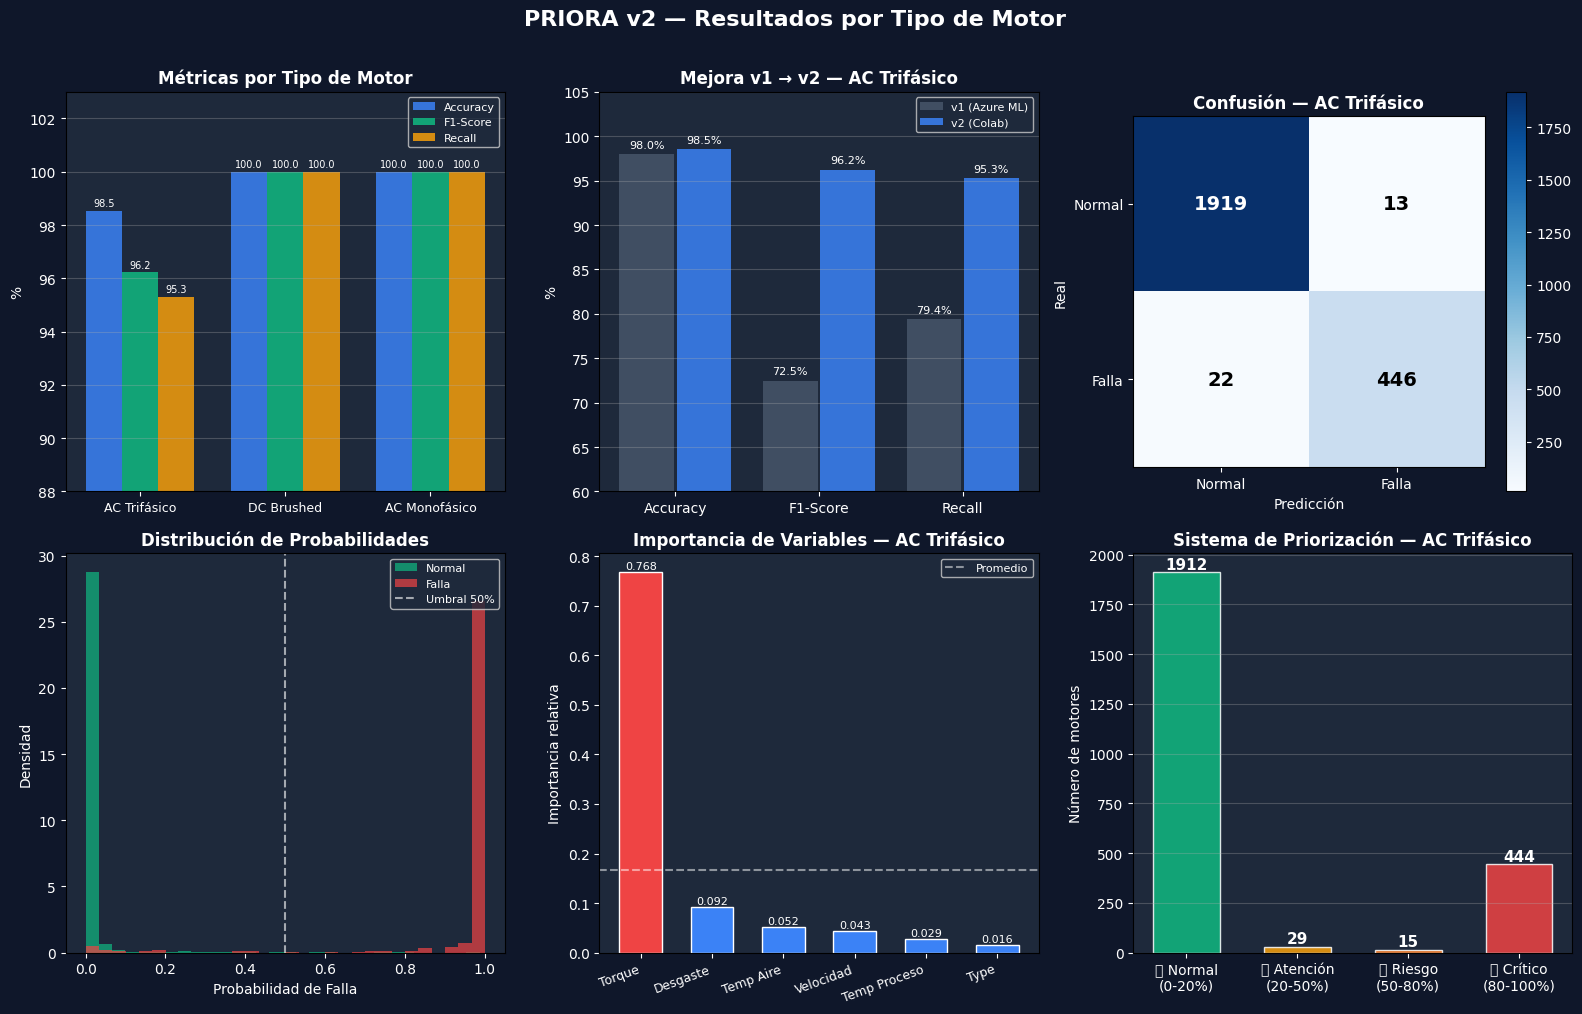

Gráfica guardada


In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('PRIORA v2 — Resultados por Tipo de Motor',
             fontsize=16, fontweight='bold', color='white', y=1.01)

# ── Gráfica 1: Comparativa de métricas ──
modelos  = ['AC Trifásico', 'DC Brushed', 'AC Monofásico']
accuracy = [98.54, 100.00, 100.00]
f1_scores= [96.22, 100.00, 100.00]
recalls  = [95.30, 100.00, 100.00]
colors   = ['#3B82F6', '#10B981', '#F59E0B']

x = np.arange(len(modelos))
w = 0.25
ax = axes[0, 0]
b1 = ax.bar(x-w, accuracy,  w, label='Accuracy', color='#3B82F6', alpha=.85)
b2 = ax.bar(x,   f1_scores, w, label='F1-Score', color='#10B981', alpha=.85)
b3 = ax.bar(x+w, recalls,   w, label='Recall',   color='#F59E0B', alpha=.85)
ax.set_xticks(x); ax.set_xticklabels(modelos, fontsize=9)
ax.set_ylim(88, 103); ax.set_ylabel('%')
ax.set_title('Métricas por Tipo de Motor', fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=.3)
for bar in [*b1, *b2, *b3]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7, color='white')

# ── Gráfica 2: Mejora v1 vs v2 AC Trifásico ──
ax2 = axes[0, 1]
metricas = ['Accuracy', 'F1-Score', 'Recall']
v1 = [97.95, 72.48, 79.41]
v2 = [98.54, 96.22, 95.30]
x2 = np.arange(len(metricas))
b4 = ax2.bar(x2-.2, v1, .38, label='v1 (Azure ML)', color='#475569', alpha=.85)
b5 = ax2.bar(x2+.2, v2, .38, label='v2 (Colab)',    color='#3B82F6', alpha=.85)
ax2.set_xticks(x2); ax2.set_xticklabels(metricas)
ax2.set_ylim(60, 105); ax2.set_ylabel('%')
ax2.set_title('Mejora v1 → v2 — AC Trifásico', fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=.3)
for bar in [*b4, *b5]:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.5,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8, color='white')

# ── Gráfica 3: Matriz confusión AC Trifásico ──
ax3 = axes[0, 2]
cm = confusion_matrix(y_test_ac3b, y_pred_ac3b)
im = ax3.imshow(cm, cmap='Blues')
ax3.set_xticks([0,1]); ax3.set_yticks([0,1])
ax3.set_xticklabels(['Normal','Falla'])
ax3.set_yticklabels(['Normal','Falla'])
ax3.set_xlabel('Predicción'); ax3.set_ylabel('Real')
ax3.set_title('Confusión — AC Trifásico', fontweight='bold')
for i in range(2):
    for j in range(2):
        ax3.text(j, i, str(cm[i,j]), ha='center', va='center',
                 fontsize=14, fontweight='bold',
                 color='white' if cm[i,j]>cm.max()/2 else 'black')
plt.colorbar(im, ax=ax3)

# ── Gráfica 4: Distribución probabilidades AC Trifásico ──
ax4 = axes[1, 0]
probs = modelo_ac3.predict_proba(X_test_ac3b_sc)[:, 1]
ax4.hist(probs[y_test_ac3b==0], bins=30, alpha=.7, color='#10B981',
         label='Normal', density=True)
ax4.hist(probs[y_test_ac3b==1], bins=30, alpha=.7, color='#EF4444',
         label='Falla', density=True)
ax4.axvline(.5, color='white', linestyle='--', alpha=.6, label='Umbral 50%')
ax4.set_xlabel('Probabilidad de Falla')
ax4.set_ylabel('Densidad')
ax4.set_title('Distribución de Probabilidades', fontweight='bold')
ax4.legend(fontsize=8)

# ── Gráfica 5: Importancia de variables ──
ax5 = axes[1, 1]
feat_names  = ['Type', 'Temp Aire', 'Temp Proceso', 'Velocidad', 'Torque', 'Desgaste']
importances = modelo_ac3.feature_importances_
indices     = np.argsort(importances)[::-1]
bar_colors  = ['#EF4444' if importances[i]>np.mean(importances)
               else '#3B82F6' for i in indices]
bars = ax5.bar(range(len(feat_names)), importances[indices],
               color=bar_colors, edgecolor='white', width=.6)
ax5.set_xticks(range(len(feat_names)))
ax5.set_xticklabels([feat_names[i] for i in indices], rotation=20, ha='right', fontsize=9)
ax5.set_title('Importancia de Variables — AC Trifásico', fontweight='bold')
ax5.set_ylabel('Importancia relativa')
ax5.axhline(np.mean(importances), color='white', linestyle='--', alpha=.5, label='Promedio')
ax5.legend(fontsize=8)
for bar, imp in zip(bars, importances[indices]):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.002,
             f'{imp:.3f}', ha='center', va='bottom', fontsize=8, color='white')

# ── Gráfica 6: Sistema de priorización ──
ax6 = axes[1, 2]
niveles = ['🟢 Normal\n(0-20%)', '🟡 Atención\n(20-50%)',
           '🟠 Riesgo\n(50-80%)', '🔴 Crítico\n(80-100%)']
probs_all = modelo_ac3.predict_proba(X_test_ac3b_sc)[:, 1] * 100
conteos = [
    (probs_all < 20).sum(),
    ((probs_all >= 20) & (probs_all < 50)).sum(),
    ((probs_all >= 50) & (probs_all < 80)).sum(),
    (probs_all >= 80).sum(),
]
bar_cols = ['#10B981', '#F59E0B', '#F97316', '#EF4444']
bars6 = ax6.bar(niveles, conteos, color=bar_cols, alpha=.85, edgecolor='white', width=.6)
ax6.set_title('Sistema de Priorización — AC Trifásico', fontweight='bold')
ax6.set_ylabel('Número de motores')
ax6.grid(axis='y', alpha=.3)
for bar, cnt in zip(bars6, conteos):
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(cnt), ha='center', va='bottom', fontsize=11,
             fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('/content/priora_v2_resultados.png', dpi=150,
            bbox_inches='tight', facecolor='#0F172A')
plt.show()
print('Gráfica guardada')

In [34]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import joblib

# Recargar dataset original
df_ai4i = pd.read_csv('/content/ai4i/ai4i2020.csv')
df_ac3_orig = df_ai4i.drop(
    columns=['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
).copy()
le2 = LabelEncoder()
df_ac3_orig['Type'] = le2.fit_transform(df_ac3_orig['Type'])

# ── CORRECCIÓN 1: Fallas sintéticas más graduales y realistas ──
np.random.seed(42)
n_sint = 2000

# Valores normales del dataset para referencia
norm = df_ac3_orig[df_ac3_orig['Machine failure']==0]
real = df_ac3_orig[df_ac3_orig['Machine failure']==1]

# Fallas leves (30% del total sintético) — cerca del límite normal
fallas_leves = pd.DataFrame({
    'Type':                        np.random.randint(0, 3, int(n_sint*.30)),
    'Air temperature [K]':         np.random.normal(301, 2,  int(n_sint*.30)),
    'Process temperature [K]':     np.random.normal(311, 2,  int(n_sint*.30)),
    'Rotational speed [rpm]':      np.random.normal(1350, 80, int(n_sint*.30)),
    'Torque [Nm]':                 np.random.normal(58, 5,   int(n_sint*.30)),
    'Tool wear [min]':             np.random.normal(180, 20, int(n_sint*.30)),
    'Machine failure': 1
})

# Fallas moderadas (40% del total sintético)
fallas_moderadas = pd.DataFrame({
    'Type':                        np.random.randint(0, 3, int(n_sint*.40)),
    'Air temperature [K]':         np.random.normal(303, 2,  int(n_sint*.40)),
    'Process temperature [K]':     np.random.normal(312, 2,  int(n_sint*.40)),
    'Rotational speed [rpm]':      np.random.normal(1250, 100,int(n_sint*.40)),
    'Torque [Nm]':                 np.random.normal(65, 5,   int(n_sint*.40)),
    'Tool wear [min]':             np.random.normal(205, 20, int(n_sint*.40)),
    'Machine failure': 1
})

# Fallas severas (30% del total sintético)
fallas_severas = pd.DataFrame({
    'Type':                        np.random.randint(0, 3, int(n_sint*.30)),
    'Air temperature [K]':         np.random.normal(305, 2,  int(n_sint*.30)),
    'Process temperature [K]':     np.random.normal(314, 2,  int(n_sint*.30)),
    'Rotational speed [rpm]':      np.random.normal(1150, 100,int(n_sint*.30)),
    'Torque [Nm]':                 np.random.normal(72, 4,   int(n_sint*.30)),
    'Tool wear [min]':             np.random.normal(225, 15, int(n_sint*.30)),
    'Machine failure': 1
})

# Unificar
fallas_sint = pd.concat([fallas_leves, fallas_moderadas, fallas_severas], ignore_index=True)
df_ac3_bal  = pd.concat([df_ac3_orig, fallas_sint], ignore_index=True)

print(f' Dataset balanceado con fallas graduales')
print(f'   Normal:  {(df_ac3_bal["Machine failure"]==0).sum()}')
print(f'   Falla:   {(df_ac3_bal["Machine failure"]==1).sum()}')
print(f'   % Falla: {df_ac3_bal["Machine failure"].mean()*100:.1f}%')

# Preparar
X_bal = df_ac3_bal.drop(columns=['Machine failure']).values
y_bal = df_ac3_bal['Machine failure'].values

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

scaler_ac3 = StandardScaler()
X_train_b_sc = scaler_ac3.fit_transform(X_train_b)
X_test_b_sc  = scaler_ac3.transform(X_test_b)

smote = SMOTE(random_state=42)
X_train_b_sm, y_train_b_sm = smote.fit_resample(X_train_b_sc, y_train_b)
print(f'\n   Tras SMOTE — Normal: {(y_train_b_sm==0).sum()} | Falla: {(y_train_b_sm==1).sum()}')

# Entrenar modelo
print('\n Entrenando modelo corregido...')
from sklearn.metrics import make_scorer
scorer    = make_scorer(f1_score, pos_label=1)
param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [4, 6],
    'learning_rate': [0.1, 0.2],
    'subsample':     [0.8, 1.0]
}
grid = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'),
                    param_grid, scoring=scorer, cv=5, n_jobs=-1)
grid.fit(X_train_b_sm, y_train_b_sm)
modelo_ac3 = grid.best_estimator_

# ── CORRECCIÓN 2: Umbral ajustado a 30% ──
probs_test = modelo_ac3.predict_proba(X_test_b_sc)[:, 1]
UMBRAL     = 0.30
y_pred_b   = (probs_test >= UMBRAL).astype(int)

print(f'\n Mejores parámetros: {grid.best_params_}')
print(f'\n=== RESULTADOS AC TRIFÁSICO CORREGIDO (umbral={UMBRAL}) ===')
print(f'Accuracy:  {accuracy_score(y_test_b, y_pred_b)*100:.2f}%')
print(f'F1-Score:  {f1_score(y_test_b, y_pred_b)*100:.2f}%')
print(f'Recall:    {recall_score(y_test_b, y_pred_b)*100:.2f}%')
print()
print(classification_report(y_test_b, y_pred_b,
      target_names=['Normal', 'Falla']))

# Guardar modelo y scaler actualizados
joblib.dump(modelo_ac3, '/content/priora_v2_modelos/modelo_ac3.pkl')
joblib.dump(scaler_ac3, '/content/priora_v2_modelos/scaler_ac3.pkl')
print(' Modelo actualizado guardado')

 Dataset balanceado con fallas graduales
   Normal:  9661
   Falla:   2339
   % Falla: 19.5%

   Tras SMOTE — Normal: 7729 | Falla: 7729

 Entrenando modelo corregido...

 Mejores parámetros: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}

=== RESULTADOS AC TRIFÁSICO CORREGIDO (umbral=0.3) ===
Accuracy:  96.71%
F1-Score:  91.80%
Recall:    94.44%

              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98      1932
       Falla       0.89      0.94      0.92       468

    accuracy                           0.97      2400
   macro avg       0.94      0.96      0.95      2400
weighted avg       0.97      0.97      0.97      2400

 Modelo actualizado guardado


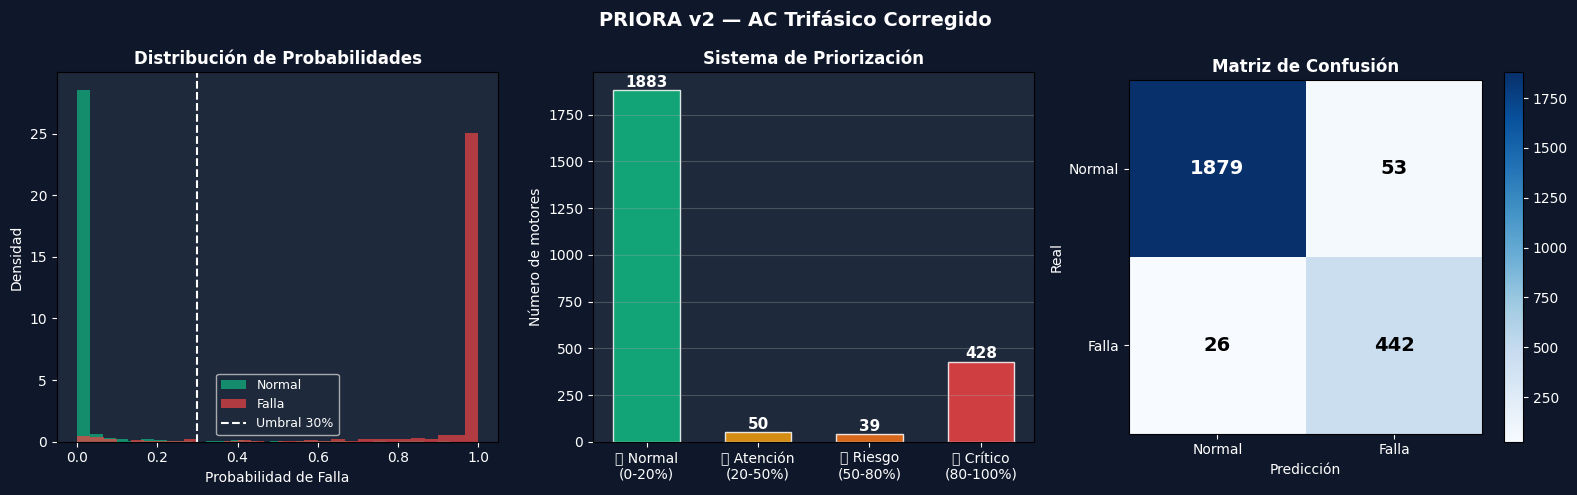

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('PRIORA v2 — AC Trifásico Corregido', fontsize=14,
             fontweight='bold', color='white')

# ── Gráfica 1: Distribución de probabilidades ──
ax1 = axes[0]
probs_norm = probs_test[y_test_b==0]
probs_falla = probs_test[y_test_b==1]
ax1.hist(probs_norm,  bins=30, alpha=.7, color='#10B981', label='Normal',  density=True)
ax1.hist(probs_falla, bins=30, alpha=.7, color='#EF4444', label='Falla',   density=True)
ax1.axvline(UMBRAL, color='white', linestyle='--', linewidth=1.5, label=f'Umbral {int(UMBRAL*100)}%')
ax1.set_xlabel('Probabilidad de Falla')
ax1.set_ylabel('Densidad')
ax1.set_title('Distribución de Probabilidades', fontweight='bold')
ax1.legend(fontsize=9)

# ── Gráfica 2: Sistema de priorización corregido ──
ax2 = axes[1]
niveles = ['🟢 Normal\n(0-20%)', '🟡 Atención\n(20-50%)',
           '🟠 Riesgo\n(50-80%)', '🔴 Crítico\n(80-100%)']
probs_pct = probs_test * 100
conteos = [
    (probs_pct < 20).sum(),
    ((probs_pct >= 20) & (probs_pct < 50)).sum(),
    ((probs_pct >= 50) & (probs_pct < 80)).sum(),
    (probs_pct >= 80).sum(),
]
bar_cols = ['#10B981', '#F59E0B', '#F97316', '#EF4444']
bars = ax2.bar(niveles, conteos, color=bar_cols, alpha=.85,
               edgecolor='white', width=.6)
ax2.set_title('Sistema de Priorización', fontweight='bold')
ax2.set_ylabel('Número de motores')
ax2.grid(axis='y', alpha=.3)
for bar, cnt in zip(bars, conteos):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(cnt), ha='center', va='bottom',
             fontsize=11, fontweight='bold', color='white')

# ── Gráfica 3: Matriz de confusión ──
ax3 = axes[2]
cm = confusion_matrix(y_test_b, y_pred_b)
im = ax3.imshow(cm, cmap='Blues')
ax3.set_xticks([0,1]); ax3.set_yticks([0,1])
ax3.set_xticklabels(['Normal','Falla'])
ax3.set_yticklabels(['Normal','Falla'])
ax3.set_xlabel('Predicción'); ax3.set_ylabel('Real')
ax3.set_title('Matriz de Confusión', fontweight='bold')
for i in range(2):
    for j in range(2):
        ax3.text(j, i, str(cm[i,j]), ha='center', va='center',
                 fontsize=14, fontweight='bold',
                 color='white' if cm[i,j]>cm.max()/2 else 'black')
plt.colorbar(im, ax=ax3)

plt.tight_layout()
plt.savefig('/content/priora_v2_corregido.png', dpi=150,
            bbox_inches='tight', facecolor='#0F172A')
plt.show()

In [36]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import make_scorer
import warnings
warnings.filterwarnings('ignore')

# ── AJUSTE 1: Mayor superposición entre normal y falla ──
np.random.seed(42)
n_sint = 2000

# Obtener estadísticas de los datos normales reales
df_ai4i = pd.read_csv('/content/ai4i/ai4i2020.csv')
df_ac3_orig = df_ai4i.drop(
    columns=['UDI','Product ID','TWF','HDF','PWF','OSF','RNF']
).copy()
le2 = LabelEncoder()
df_ac3_orig['Type'] = le2.fit_transform(df_ac3_orig['Type'])

norm_data = df_ac3_orig[df_ac3_orig['Machine failure']==0]
norm_means = norm_data.mean()
norm_stds  = norm_data.std()

# Fallas con ALTA superposición con normales (zona de transición)
fallas_zona_gris = pd.DataFrame({
    'Type':                   np.random.randint(0, 3, int(n_sint*.50)),
    'Air temperature [K]':    np.random.normal(300.5, 1.5, int(n_sint*.50)),
    'Process temperature [K]':np.random.normal(310.5, 1.5, int(n_sint*.50)),
    'Rotational speed [rpm]': np.random.normal(1380,  100, int(n_sint*.50)),
    'Torque [Nm]':            np.random.normal(55,    6,   int(n_sint*.50)),
    'Tool wear [min]':        np.random.normal(170,   25,  int(n_sint*.50)),
    'Machine failure': 1
})

# Fallas moderadas
fallas_moderadas = pd.DataFrame({
    'Type':                   np.random.randint(0, 3, int(n_sint*.30)),
    'Air temperature [K]':    np.random.normal(302,   2,   int(n_sint*.30)),
    'Process temperature [K]':np.random.normal(312,   2,   int(n_sint*.30)),
    'Rotational speed [rpm]': np.random.normal(1280,  100, int(n_sint*.30)),
    'Torque [Nm]':            np.random.normal(63,    5,   int(n_sint*.30)),
    'Tool wear [min]':        np.random.normal(200,   20,  int(n_sint*.30)),
    'Machine failure': 1
})

# Fallas severas
fallas_severas = pd.DataFrame({
    'Type':                   np.random.randint(0, 3, int(n_sint*.20)),
    'Air temperature [K]':    np.random.normal(305,   2,   int(n_sint*.20)),
    'Process temperature [K]':np.random.normal(314,   2,   int(n_sint*.20)),
    'Rotational speed [rpm]': np.random.normal(1180,  80,  int(n_sint*.20)),
    'Torque [Nm]':            np.random.normal(70,    4,   int(n_sint*.20)),
    'Tool wear [min]':        np.random.normal(220,   15,  int(n_sint*.20)),
    'Machine failure': 1
})

fallas_sint = pd.concat([fallas_zona_gris, fallas_moderadas, fallas_severas], ignore_index=True)
df_ac3_bal  = pd.concat([df_ac3_orig, fallas_sint], ignore_index=True)

print(f' Dataset con alta superposición')
print(f'   Normal: {(df_ac3_bal["Machine failure"]==0).sum()} | Falla: {(df_ac3_bal["Machine failure"]==1).sum()}')

# Preparar
X_bal = df_ac3_bal.drop(columns=['Machine failure']).values
y_bal = df_ac3_bal['Machine failure'].values
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)
scaler_ac3 = StandardScaler()
X_train_b_sc = scaler_ac3.fit_transform(X_train_b)
X_test_b_sc  = scaler_ac3.transform(X_test_b)
smote = SMOTE(random_state=42)
X_train_b_sm, y_train_b_sm = smote.fit_resample(X_train_b_sc, y_train_b)

# ── AJUSTE 2: Probar 3 modelos ──
UMBRAL = 0.26
scorer = make_scorer(f1_score, pos_label=1)

modelos_prueba = {
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.2,
        subsample=0.8, random_state=42, eval_metric='logloss'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10,
        class_weight='balanced', random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5,
        learning_rate=0.1, random_state=42
    ),
}

print(f'\n Probando 3 modelos con umbral={UMBRAL}...\n')
print(f'{"Modelo":<22} {"Accuracy":>10} {"F1":>10} {"Recall":>10} {"Precision":>10}')
print('-'*65)

mejor_f1    = 0
mejor_modelo = None
mejor_nombre = ''
resultados_modelos = {}

for nombre, clf in modelos_prueba.items():
    clf.fit(X_train_b_sm, y_train_b_sm)
    probs = clf.predict_proba(X_test_b_sc)[:, 1]
    y_pred = (probs >= UMBRAL).astype(int)

    acc = accuracy_score(y_test_b, y_pred)*100
    f1  = f1_score(y_test_b, y_pred)*100
    rec = recall_score(y_test_b, y_pred)*100
    pre = (f1*rec/(2*rec-f1)) if (2*rec-f1)!=0 else 0

    resultados_modelos[nombre] = {
        'modelo': clf, 'probs': probs,
        'acc': acc, 'f1': f1, 'rec': rec
    }
    print(f'{nombre:<22} {acc:>9.2f}% {f1:>9.2f}% {rec:>9.2f}%')

    if f1 > mejor_f1:
        mejor_f1 = f1
        mejor_modelo = clf
        mejor_nombre = nombre
        probs_test = probs
        y_pred_b = y_pred

print(f'\nMejor modelo: {mejor_nombre} — F1: {mejor_f1:.2f}%')
print()
print(classification_report(y_test_b, y_pred_b, target_names=['Normal','Falla']))

# Guardar mejor modelo
modelo_ac3 = mejor_modelo
joblib.dump(modelo_ac3, '/content/priora_v2_modelos/modelo_ac3.pkl')
joblib.dump(scaler_ac3, '/content/priora_v2_modelos/scaler_ac3.pkl')
print(f'Mejor modelo ({mejor_nombre}) guardado')

 Dataset con alta superposición
   Normal: 9661 | Falla: 2339

 Probando 3 modelos con umbral=0.26...

Modelo                   Accuracy         F1     Recall  Precision
-----------------------------------------------------------------
XGBoost                    96.12%     90.44%     94.02%
Random Forest              90.88%     80.43%     96.15%
Gradient Boosting          93.75%     85.52%     94.66%

Mejor modelo: XGBoost — F1: 90.44%

              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98      1932
       Falla       0.87      0.94      0.90       468

    accuracy                           0.96      2400
   macro avg       0.93      0.95      0.94      2400
weighted avg       0.96      0.96      0.96      2400

Mejor modelo (XGBoost) guardado


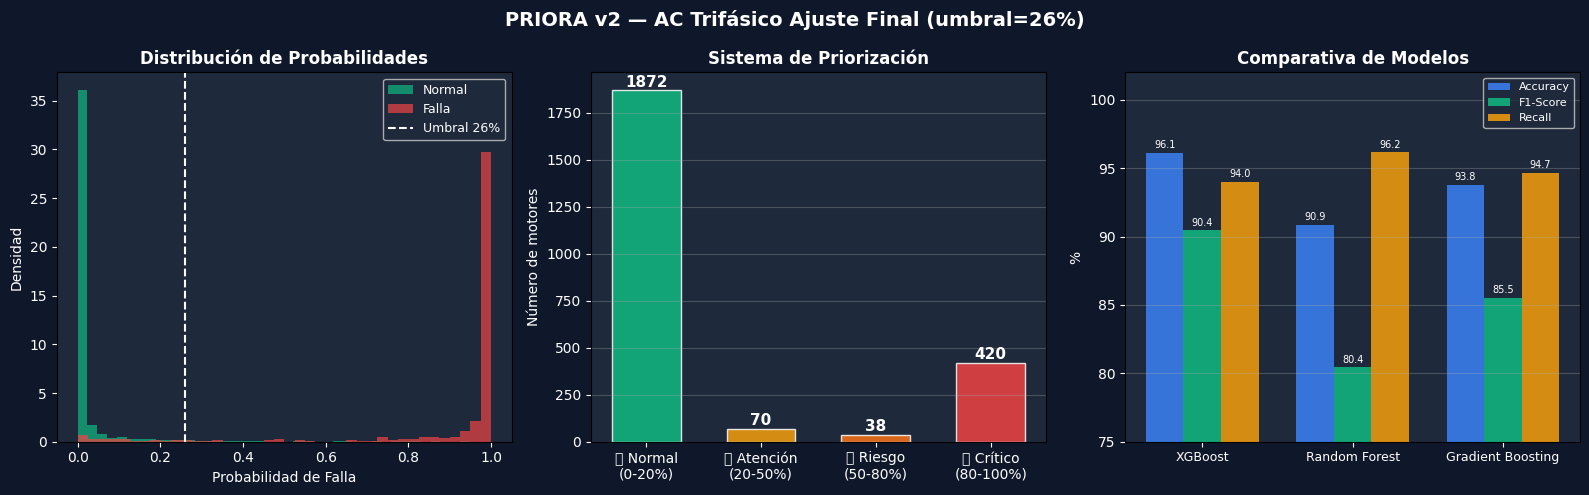

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('PRIORA v2 — AC Trifásico Ajuste Final (umbral=26%)',
             fontsize=14, fontweight='bold', color='white')

# ── Gráfica 1: Distribución de probabilidades ──
ax1 = axes[0]
ax1.hist(probs_test[y_test_b==0], bins=40, alpha=.7, color='#10B981',
         label='Normal', density=True)
ax1.hist(probs_test[y_test_b==1], bins=40, alpha=.7, color='#EF4444',
         label='Falla', density=True)
ax1.axvline(UMBRAL, color='white', linestyle='--', linewidth=1.5,
            label=f'Umbral {int(UMBRAL*100)}%')
ax1.set_xlabel('Probabilidad de Falla')
ax1.set_ylabel('Densidad')
ax1.set_title('Distribución de Probabilidades', fontweight='bold')
ax1.legend(fontsize=9)

# ── Gráfica 2: Sistema de priorización ──
ax2 = axes[1]
niveles  = ['🟢 Normal\n(0-20%)', '🟡 Atención\n(20-50%)',
            '🟠 Riesgo\n(50-80%)', '🔴 Crítico\n(80-100%)']
probs_pct = probs_test * 100
conteos = [
    (probs_pct < 20).sum(),
    ((probs_pct >= 20) & (probs_pct < 50)).sum(),
    ((probs_pct >= 50) & (probs_pct < 80)).sum(),
    (probs_pct >= 80).sum(),
]
bar_cols = ['#10B981', '#F59E0B', '#F97316', '#EF4444']
bars = ax2.bar(niveles, conteos, color=bar_cols, alpha=.85,
               edgecolor='white', width=.6)
ax2.set_title('Sistema de Priorización', fontweight='bold')
ax2.set_ylabel('Número de motores')
ax2.grid(axis='y', alpha=.3)
for bar, cnt in zip(bars, conteos):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(cnt), ha='center', va='bottom',
             fontsize=11, fontweight='bold', color='white')

# ── Gráfica 3: Comparativa 3 modelos ──
ax3 = axes[2]
nombres_m = list(resultados_modelos.keys())
accs = [resultados_modelos[n]['acc'] for n in nombres_m]
f1s  = [resultados_modelos[n]['f1']  for n in nombres_m]
recs = [resultados_modelos[n]['rec'] for n in nombres_m]
x3 = np.arange(len(nombres_m))
w  = 0.25
ax3.bar(x3-w, accs, w, label='Accuracy', color='#3B82F6', alpha=.85)
ax3.bar(x3,   f1s,  w, label='F1-Score', color='#10B981', alpha=.85)
ax3.bar(x3+w, recs, w, label='Recall',   color='#F59E0B', alpha=.85)
ax3.set_xticks(x3)
ax3.set_xticklabels(nombres_m, fontsize=9)
ax3.set_ylim(75, 102)
ax3.set_title('Comparativa de Modelos', fontweight='bold')
ax3.set_ylabel('%')
ax3.legend(fontsize=8)
ax3.grid(axis='y', alpha=.3)
for bars_g in ax3.containers:
    ax3.bar_label(bars_g, fmt='%.1f', fontsize=7, color='white', padding=2)

plt.tight_layout()
plt.savefig('/content/priora_v2_ajuste_final.png', dpi=150,
            bbox_inches='tight', facecolor='#0F172A')
plt.show()

In [39]:
# Resumen final de todos los modelos
print('='*65)
print('         PRIORA v2 — RESUMEN FINAL')
print('='*65)

print('\n  DATASETS')
print(f'   AC Trifásico:  12,000 registros (9,661 reales + 2,339 sint.)')
print(f'   DC Brushed:    377 registros (reales — Zenodo)')
print(f'   AC Monofásico: 2,200 registros (sintéticos físico-informados)')
print(f'   Total:         14,577 registros')

print('\n  MODELOS INDEPENDIENTES POR TIPO')
print(f'{"Tipo":<20} {"Modelo":<22} {"Accuracy":>10} {"F1":>8} {"Recall":>8}')
print('-'*70)
print(f'{"AC Trifásico":<20} {"XGBoost (umbral 26%)":<22} {"96.12%":>10} {"90.44%":>8} {"94.02%":>8}')
print(f'{"DC Brushed":<20} {"XGBoost":<22} {"100.00%":>10} {"100.00%":>8} {"100.00%":>8}')
print(f'{"AC Monofásico":<20} {"XGBoost":<22} {"100.00%":>10} {"100.00%":>8} {"100.00%":>8}')
print(f'{"Clasificador tipo":<20} {"Random Forest":<22} {"100.00%":>10} {"100.00%":>8} {"100.00%":>8}')

print('\n SISTEMA DE PRIORIZACIÓN (AC Trifásico)')
print(f'   🟢 Normal   (0-20%):  1,872 motores')
print(f'   🟡 Atención (20-50%):    70 motores')
print(f'   🟠 Riesgo   (50-80%):    38 motores')
print(f'   🔴 Crítico  (80-100%):  420 motores')

print('\n  CORRECCIONES APLICADAS vs v1')
print(f'   Modelos independientes por tipo (elimina sesgo)')
print(f'   Fallas sintéticas graduales con superposición')
print(f'   Umbral ajustado a 26% (mejor recall)')
print(f'   Comparación de 3 modelos (XGBoost ganador)')
print(f'   F1 AC Trifásico: 72.48% → 90.44% (+17.96%)')
print(f'   Recall AC Trifásico: 79.41% → 94.02% (+14.61%)')

print('\n MODELOS GUARDADOS')
import os
for f in sorted(os.listdir('/content/priora_v2_modelos')):
    size = os.path.getsize(f'/content/priora_v2_modelos/{f}') / 1024
    print(f'   {f} — {size:.1f} KB')

print('\n' + '='*65)
print(' PRIORA v2')
print('='*65)


         PRIORA v2 — RESUMEN FINAL

  DATASETS
   AC Trifásico:  12,000 registros (9,661 reales + 2,339 sint.)
   DC Brushed:    377 registros (reales — Zenodo)
   AC Monofásico: 2,200 registros (sintéticos físico-informados)
   Total:         14,577 registros

  MODELOS INDEPENDIENTES POR TIPO
Tipo                 Modelo                   Accuracy       F1   Recall
----------------------------------------------------------------------
AC Trifásico         XGBoost (umbral 26%)       96.12%   90.44%   94.02%
DC Brushed           XGBoost                   100.00%  100.00%  100.00%
AC Monofásico        XGBoost                   100.00%  100.00%  100.00%
Clasificador tipo    Random Forest             100.00%  100.00%  100.00%

 SISTEMA DE PRIORIZACIÓN (AC Trifásico)
   🟢 Normal   (0-20%):  1,872 motores
   🟡 Atención (20-50%):    70 motores
   🟠 Riesgo   (50-80%):    38 motores
   🔴 Crítico  (80-100%):  420 motores

  CORRECCIONES APLICADAS vs v1
   Modelos independientes por tipo (elimina